# MDC Column Charts with BCa CI

This notebook reads MDC values from `data/agreement/lmm_*.csv` and creates flexion/extension column charts with BCa CI whiskers and MCID reference lines.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [24]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

figure_colors = {
    "OMC": "black",
    "RTMW: Performance": "#3ec5ef",
    "HSMR": "#ff886b",
    "SOC": "#a274d4",
}

method_order = ['rtmw', 'hsmr', 'soc']
method_labels = ['RTMW', 'HSMR', 'SOC']
method_colors = [
    figure_colors['RTMW: Performance'],
    figure_colors['HSMR'],
    figure_colors['SOC']
]
mcid_by_motion = {'flexion': 10, 'extension': 5}

In [25]:
project_root = Path.cwd()
if (project_root / 'data' / 'agreement').exists():
    pass
elif (project_root.parent / 'data' / 'agreement').exists():
    project_root = project_root.parent
else:
    raise FileNotFoundError('Could not find data/agreement from current working directory.')

agreement_dir = project_root / 'data' / 'agreement'
out_dir = project_root / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)

files = sorted(agreement_dir.glob('lmm_*_*.csv'))
if not files:
    raise FileNotFoundError(f'No agreement CSV files found in: {agreement_dir}')

rows = []
for path in files:
    parts = path.stem.split('_')
    if len(parts) != 3:
        continue
    _, method, motion = parts

    df = pd.read_csv(path)
    mdc_row = df[df['metric'] == 'mdc']
    if mdc_row.empty:
        continue

    rows.append({
        'method': method,
        'motion': motion,
        'mdc': float(mdc_row['point_estimate'].iloc[0]),
        'lower': float(mdc_row['bca_lower_ci'].iloc[0]),
        'upper': float(mdc_row['bca_upper_ci'].iloc[0])
    })

mdc_df = pd.DataFrame(rows)
mdc_df

,method,motion,mdc,lower,upper
0,hsmr,extension,6.359965,5.710328,8.119837
1,hsmr,flexion,6.743248,6.036454,8.809988
2,rtmw,extension,7.934316,6.960921,10.559823
3,rtmw,flexion,6.871769,5.721652,9.280519
4,soc,extension,5.609944,4.840779,7.532811
5,soc,flexion,7.992745,7.557366,9.330295


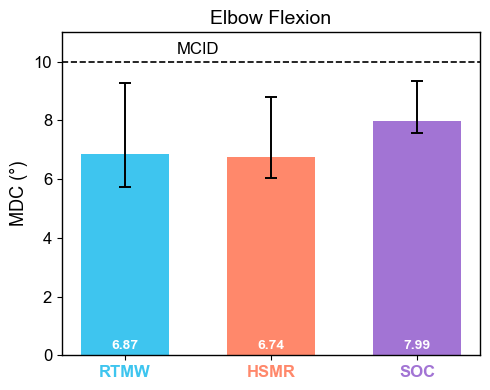

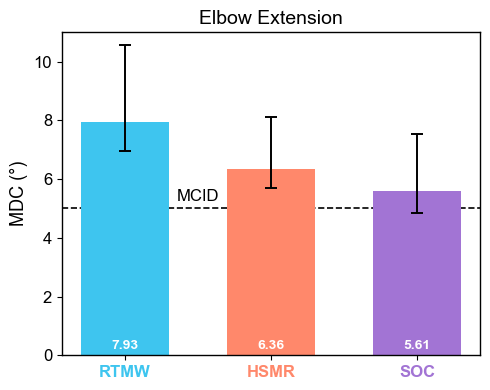

In [26]:
def plot_mdc_motion(motion, out_stem):
    subset = (
        mdc_df[mdc_df['motion'] == motion]
        .set_index('method')
        .reindex(method_order)
        .reset_index()
    )

    x = np.arange(len(method_order))
    y = subset['mdc'].to_numpy()
    yerr_lower = y - subset['lower'].to_numpy()
    yerr_upper = subset['upper'].to_numpy() - y

    fig, ax = plt.subplots(1, 1, figsize=(5, 4))

    ax.bar(x, y, color=method_colors, width=0.6, zorder=2)
    ax.errorbar(
        x,
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt='none',
        ecolor='black',
        elinewidth=1.4,
        capsize=4,
        capthick=1.4,
        zorder=3
    )

    for i, val in enumerate(y):
        ax.text(i, 0.10, f'{val:.2f}', ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')

    title = 'Elbow Flexion' if motion == 'flexion' else 'Elbow Extension'
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('MDC (°)', fontsize=13)
    ax.set_xlabel('')
    ax.set_xticks(x)
    ax.set_xticklabels(method_labels, fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    for tick, color in zip(ax.get_xticklabels(), method_colors):
        tick.set_color(color)

    ax.set_ylim(0, 11)
    ax.set_yticks(np.arange(0, 10.1, 2))

    mcid = mcid_by_motion[motion]
    ax.axhline(mcid, color='black', linestyle='--', linewidth=1.2, zorder=1)
    ax.text(0.5, mcid + 0.15, 'MCID', ha='center', va='bottom', color='black', fontsize=12)

    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)

    fig.tight_layout()
    fig.savefig(out_dir / f'{out_stem}.pdf', bbox_inches='tight')
    plt.show()

plot_mdc_motion('flexion', '03_mdc_flexion')
plot_mdc_motion('extension', '03_mdc_extension')